# FASHION RETAIL ANALYSIS

**Dataset Overview**

This dataset contains `3,400` records of fashion retail sales, capturing various details about customer purchases, including item details, purchase amounts, ratings, and payment methods. It is useful for analyzing customer buying behavior, product popularity, and payment preferences.

# Exploratory Data Analysis

- **Customer Reference ID** : A unique identifier for each customer.
- **Item Purchased** : The name of the fashion item purchased.
- **Purchase Amount (USD)** : The purchase price of the item in USD (650 missing values).
- **Date Purchase** : The date on which the purchase was made (format: DD-MM-YYYY).
- **Review Rating** : The customer review rating (scale: 1 to 5, 324 missing values).
- **Payment Method** : The payment method used (e.g., Credit Card, Cash)

# Key Insight
- The dataset contains 3,400 transactions.
- Missing values are present in:
  - Purchase Amount (USD): 650 missing values
  - Review Rating: 324 missing values
- Payment Method includes multiple categories, allowing analysis of payment trends.
- Date Purchase is in DD-MM-YYYY format, which can be useful for time-series analysis.
- The dataset can help analyze sales trends, customer preferences, and payment behaviors in the fashion retail industry.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

In [2]:
df_fashion_retail = pd.read_csv('Fashion_Retail_Sales.csv')
df_fashion_retail

,Customer Reference ID,Item Purchased,Purchase Amount (USD),Date Purchase,Review Rating,Payment Method
0,4018,Handbag,4619.0,05-02-2023,NaN,Credit Card
1,4115,Tunic,2456.0,11-07-2023,2.0,Credit Card
2,4019,Tank Top,2102.0,23-03-2023,4.1,Cash
3,4097,Leggings,3126.0,15-03-2023,3.2,Cash
4,3997,Wallet,3003.0,27-11-2022,4.7,Cash
...,...,...,...,...,...,...
3395,4118,Shorts,37.0,09-07-2023,2.7,Cash
3396,4056,Slippers,176.0,16-03-2023,2.5,Cash
3397,3991,Onesie,NaN,03-10-2022,2.4,Credit Card
3398,4042,Sandals,128.0,01-01-2023,1.8,Cash


In [3]:
df_fashion_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Reference ID  3400 non-null   int64  
 1   Item Purchased         3400 non-null   object 
 2   Purchase Amount (USD)  2750 non-null   float64
 3   Date Purchase          3400 non-null   object 
 4   Review Rating          3076 non-null   float64
 5   Payment Method         3400 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 159.5+ KB


In [4]:
# mengubah kolum Date Purchase menjadi datetime
df_fashion_retail['Date Purchase'] = pd.to_datetime(df_fashion_retail['Date Purchase'], format='%d-%m-%Y')
# menampilkan 5 data teratas
df_fashion_retail.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Customer Reference ID  3400 non-null   int64         
 1   Item Purchased         3400 non-null   object        
 2   Purchase Amount (USD)  2750 non-null   float64       
 3   Date Purchase          3400 non-null   datetime64[ns]
 4   Review Rating          3076 non-null   float64       
 5   Payment Method         3400 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 159.5+ KB


In [5]:
# menghilangkan (USD) pada kolom purchase amount
df_fashion_retail.rename(columns={'Purchase Amount (USD)': 'purchase_amount_usd'}, inplace=True)

In [6]:
# mengubah nama kolum menggunakan snake_case
df_fashion_retail.columns = df_fashion_retail.columns.str.lower().str.replace(' ', '_')
df_fashion_retail.columns

Index(['customer_reference_id', 'item_purchased', 'purchase_amount_usd',
       'date_purchase', 'review_rating', 'payment_method'],
      dtype='object')

Melakukan pengecekan pada missing value

In [7]:
# pengecekan pada missing value
df_fashion_retail.isnull().sum()

customer_reference_id      0
item_purchased             0
purchase_amount_usd      650
date_purchase              0
review_rating            324
payment_method             0
dtype: int64

Pada dataset tersebut tidak terdapat informasi mengapa terdapat missing value pada kolum purchase amount, dikarenakan tidak terdapat kolum `quantity` dalam setiap pembelian yang customer lakukan maka diputuskan untuk melakukan `drop` terhadap missing value tersebut 

In [8]:
#drop missing values in column Purchase Amount
df_fashion_retail.dropna(subset=['purchase_amount_usd'], inplace=True)
df_fashion_retail.isnull().sum()

customer_reference_id      0
item_purchased             0
purchase_amount_usd        0
date_purchase              0
review_rating            263
payment_method             0
dtype: int64

C:\Users\Ikhsan Herdi F\AppData\Local\Temp\ipykernel_13296\673815857.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = df_fashion_retail.resample('M', on='date_purchase')['purchase_amount_usd'].sum()


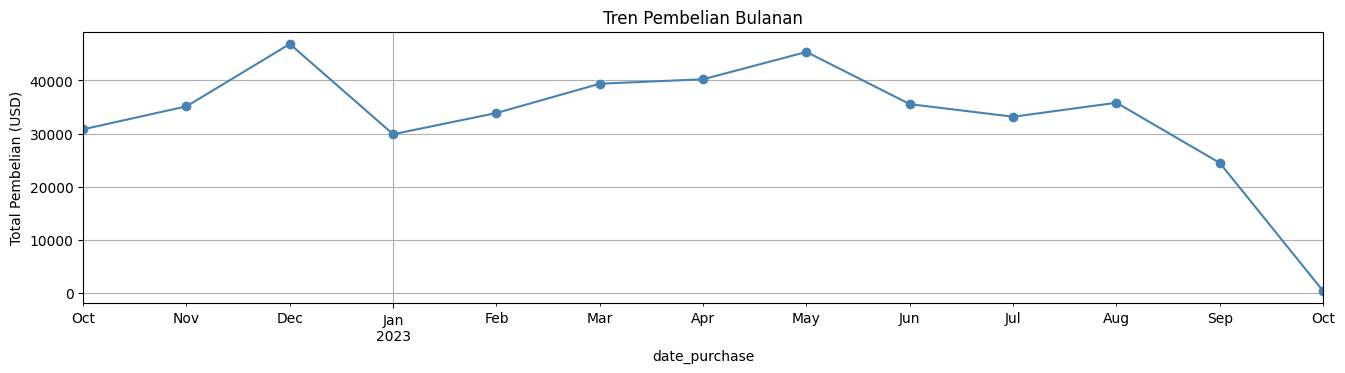

In [9]:
# Tren pembelian berdasarkan waktu (bulanan)
monthly_trend = df_fashion_retail.resample('M', on='date_purchase')['purchase_amount_usd'].sum()

# Top item berdasarkan total pendapatan
top_items_by_revenue = df_fashion_retail.groupby('item_purchased')['purchase_amount_usd'].sum().sort_values(ascending=False).head(10)

# Top item berdasarkan jumlah penjualan
top_items_by_quantity = df_fashion_retail['item_purchased'].value_counts().head(10)

# Top item berdasarkan total pendapatan
top_items_by_revenue = df_fashion_retail.groupby('item_purchased')['purchase_amount_usd'].sum().sort_values(ascending=False).head(10)

# Produk terlaris (jumlah penjualan terbanyak)
best_selling_product = top_items_by_quantity.idxmax()
best_selling_count = top_items_by_quantity.max()

# line chart tren pembelian bulanan
plt.figure(figsize=(16, 12))
plt.subplot(3, 1, 1)
monthly_trend.plot(marker='o', color='steelblue')
plt.title('Tren Pembelian Bulanan')
plt.ylabel('Total Pembelian (USD)')
plt.grid(True)


plt.show()

C:\Users\Ikhsan Herdi F\AppData\Local\Temp\ipykernel_13296\2380500856.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nov_dec_sales.values, y=nov_dec_sales.index, palette='plasma')


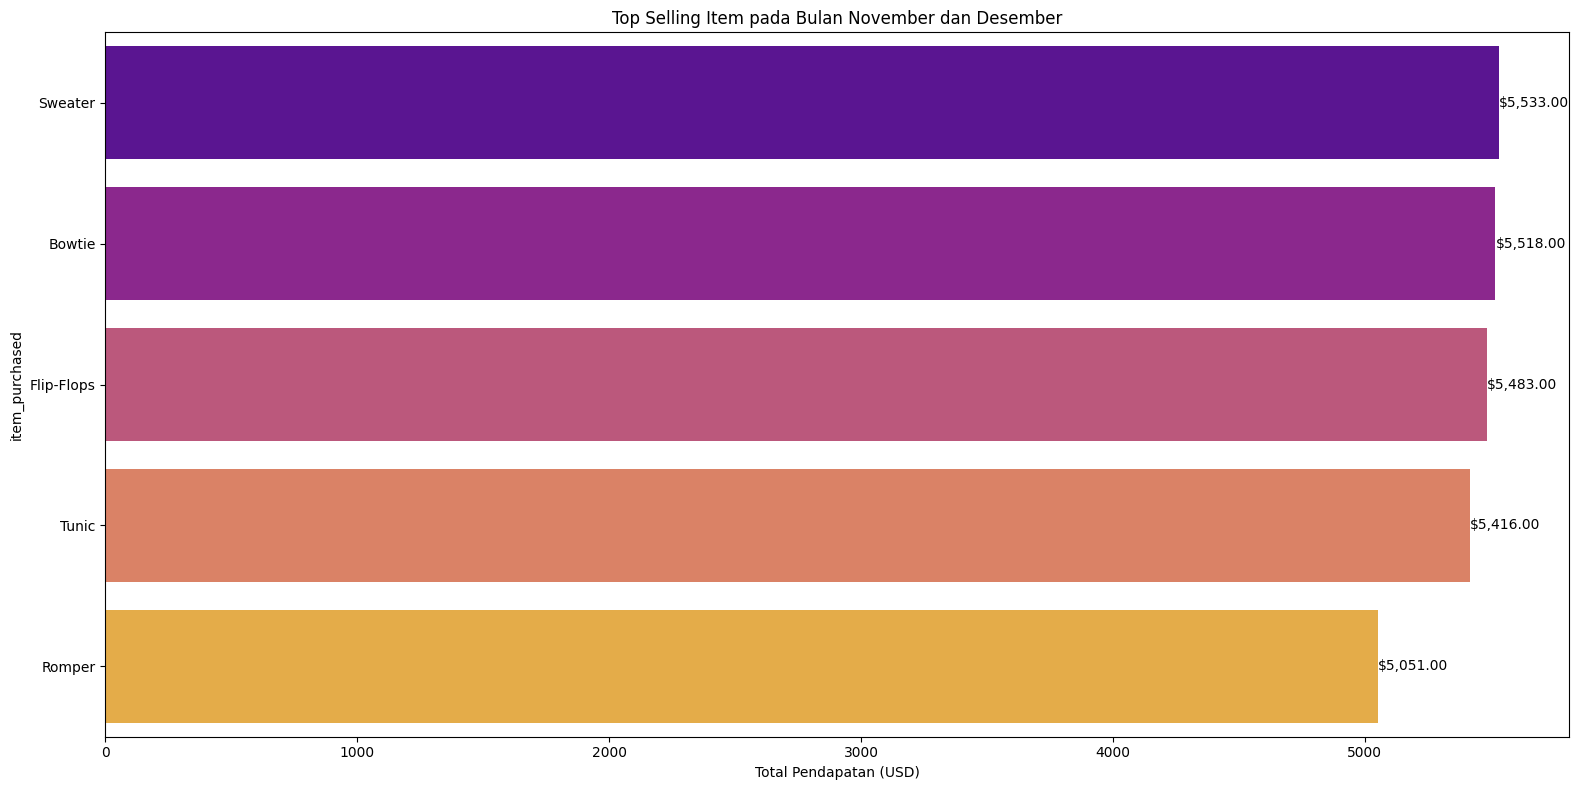

In [10]:
# penjualan item terlaris pada bulan November sampai Desember
nov_dec_sales = df_fashion_retail[(df_fashion_retail['date_purchase'].dt.month == 11) | (df_fashion_retail['date_purchase'].dt.month == 12)]
nov_dec_sales = nov_dec_sales.groupby('item_purchased')['purchase_amount_usd'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(16, 8))
sns.barplot(x=nov_dec_sales.values, y=nov_dec_sales.index, palette='plasma')
for i, v in enumerate(nov_dec_sales.values):
    plt.text(v + 0.5, i, f'${v:,.2f}', color='black', va='center', fontsize=10)
plt.title('Top Selling Item pada Bulan November dan Desember')
plt.xlabel('Total Pendapatan (USD)')
plt.tight_layout()
plt.show()

C:\Users\Ikhsan Herdi F\AppData\Local\Temp\ipykernel_13296\913592674.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nov_dec_sales.values, y=nov_dec_sales.index, palette='plasma')


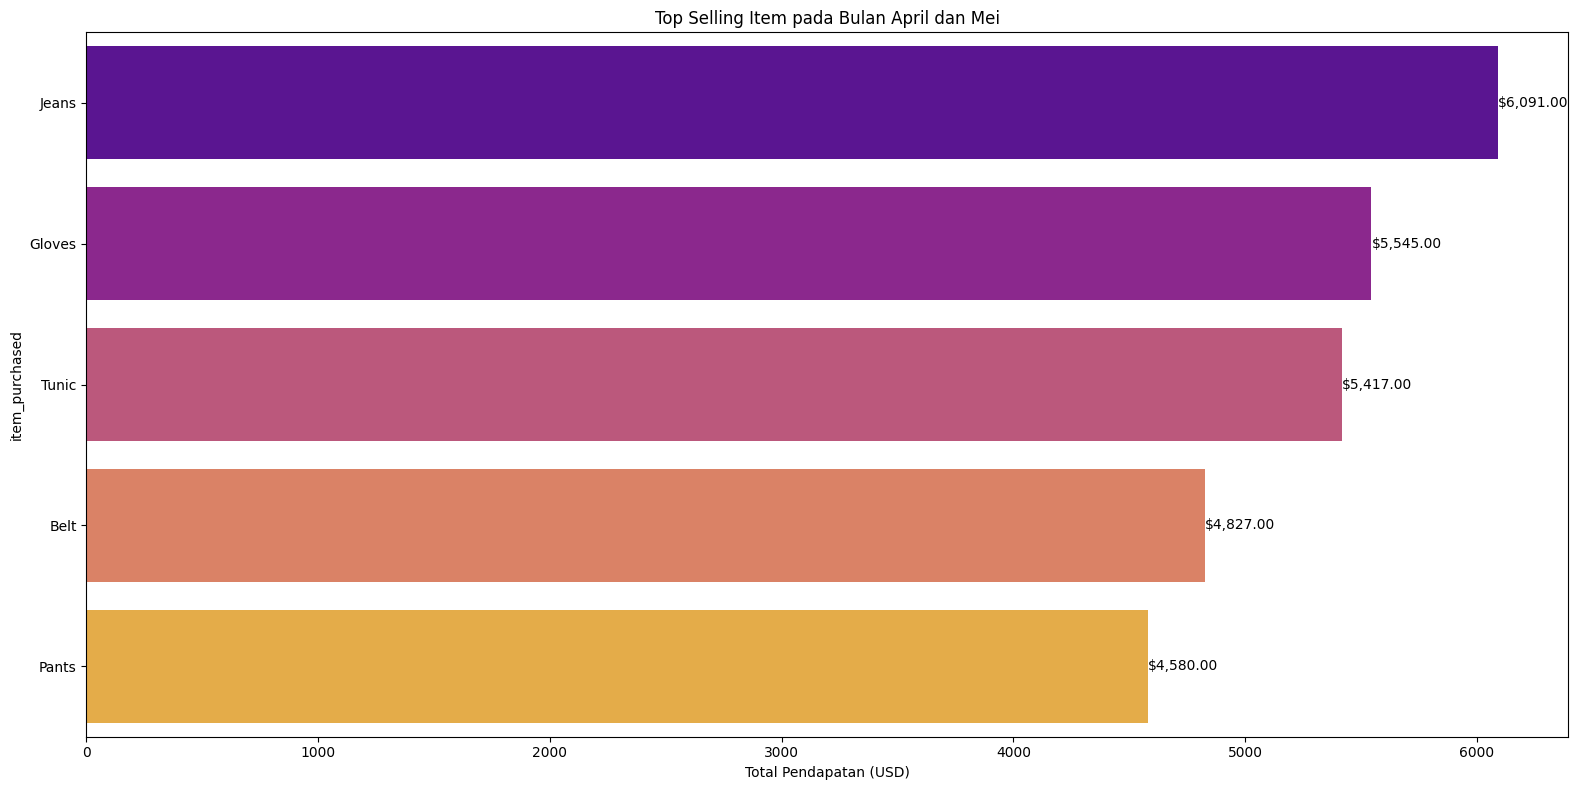

In [11]:
# penjualan item terlaris pada bulan November sampai Desember
nov_dec_sales = df_fashion_retail[(df_fashion_retail['date_purchase'].dt.month == 4) | (df_fashion_retail['date_purchase'].dt.month == 5)]
nov_dec_sales = nov_dec_sales.groupby('item_purchased')['purchase_amount_usd'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(16, 8))
sns.barplot(x=nov_dec_sales.values, y=nov_dec_sales.index, palette='plasma')
for i, v in enumerate(nov_dec_sales.values):
    plt.text(v + 0.5, i, f'${v:,.2f}', color='black', va='center', fontsize=10)
plt.title('Top Selling Item pada Bulan April dan Mei')
plt.xlabel('Total Pendapatan (USD)')
plt.tight_layout()
plt.show()

Dari grafik dan analisis berikut kita dapat melihat kenaikan tren penjualan tertinggi terdapat pada holiday season (Winter Holiday dan Summer Holiday) pada bulan ke 11-12 dan 4-5 di tahun tersebut, rekomendasi yang dapat dilakukan yaitu meningkatkan promosi dan stock item dengan harapan dapat meningkatkan jumlah tren penjualan di tahun berikutnya.

C:\Users\Ikhsan Herdi F\AppData\Local\Temp\ipykernel_13296\1601706513.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_items_by_quantity.values, y=top_items_by_quantity.index, palette='viridis')


Text(0.5, 0, 'Jumlah Terjual')

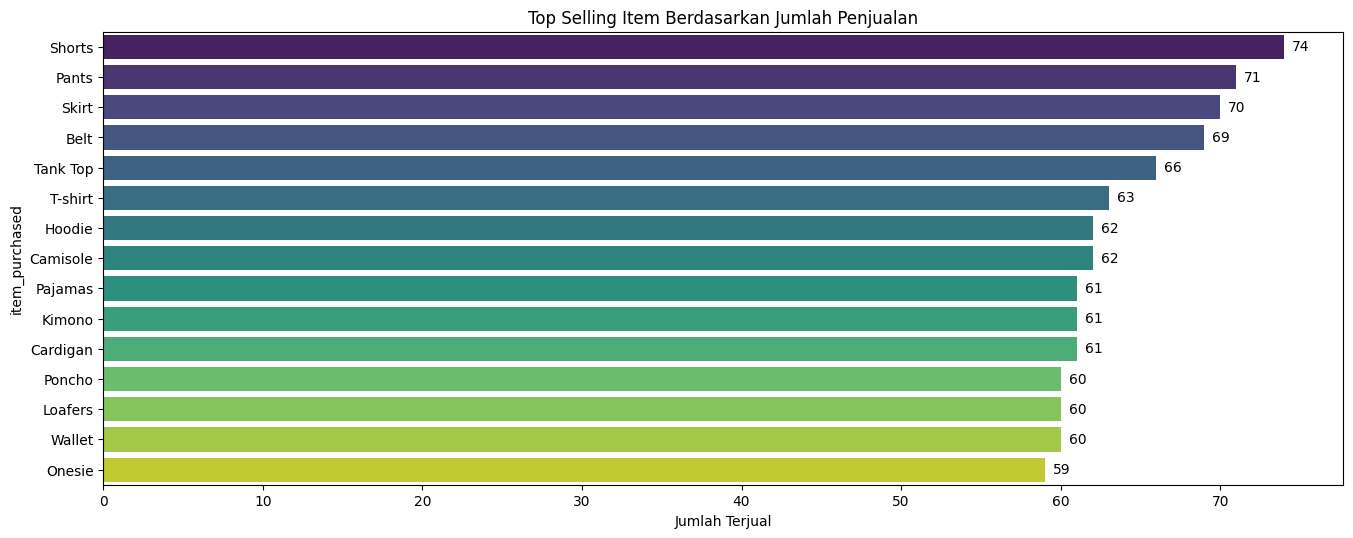

In [12]:
top_items_by_quantity = df_fashion_retail['item_purchased'].value_counts().head(15)

# Item berdasarkan Jumlah Penjualan
plt.figure(figsize=(16, 20))
plt.subplot(3, 1, 2)
sns.barplot(x=top_items_by_quantity.values, y=top_items_by_quantity.index, palette='viridis')
for i, v in enumerate(top_items_by_quantity.values):
    plt.text(v + 0.5, i, str(v), color='black', va='center', fontsize=10)
plt.title('Top Selling Item Berdasarkan Jumlah Penjualan')
plt.xlabel('Jumlah Terjual')

Item-item fashion yang paling banyak terjual didominasi oleh produk-produk tertentu yang memiliki permintaan tinggi. Hal ini bisa mencerminkan tren atau preferensi konsumen saat ini. Retailer dapat fokus pada stok dan promosi produk-produk ini untuk meningkatkan pendapatan serta mempertahankan loyalitas pelanggan. Selain itu, produk dengan performa tinggi bisa menjadi acuan untuk pengembangan produk baru yang serupa

C:\Users\Ikhsan Herdi F\AppData\Local\Temp\ipykernel_13296\2108346298.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_items_by_revenue.values, y=top_items_by_revenue.index, palette='magma')


Text(0.5, 0, 'Total Pendapatan (USD)')

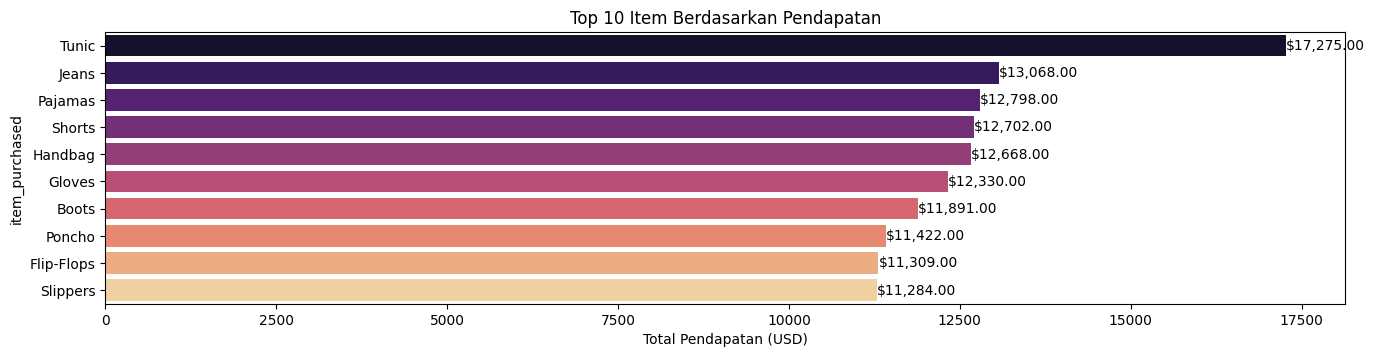

In [13]:
plt.figure(figsize=(16, 12))
plt.subplot(3, 1, 3)
sns.barplot(x=top_items_by_revenue.values, y=top_items_by_revenue.index, palette='magma')
for i, v in enumerate(top_items_by_revenue.values):
    plt.text(v + 0.5, i, f'${v:,.2f}', color='black', va='center', fontsize=10)
plt.title('Top 10 Item Berdasarkan Pendapatan')
plt.xlabel('Total Pendapatan (USD)')

Item-item yang menghasilkan pendapatan tertinggi tidak selalu merupakan item yang paling banyak terjual. Ini menunjukkan bahwa ada produk-produk dengan margin harga tinggi yang berkontribusi signifikan terhadap total revenue. Retailer dapat memanfaatkan hal ini untuk menyusun strategi upselling atau menyoroti produk high-ticket melalui promosi eksklusif dan bundling

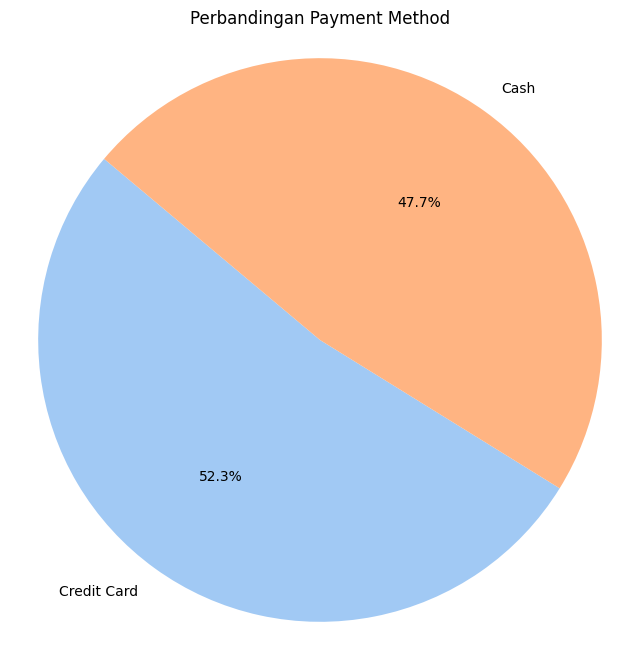

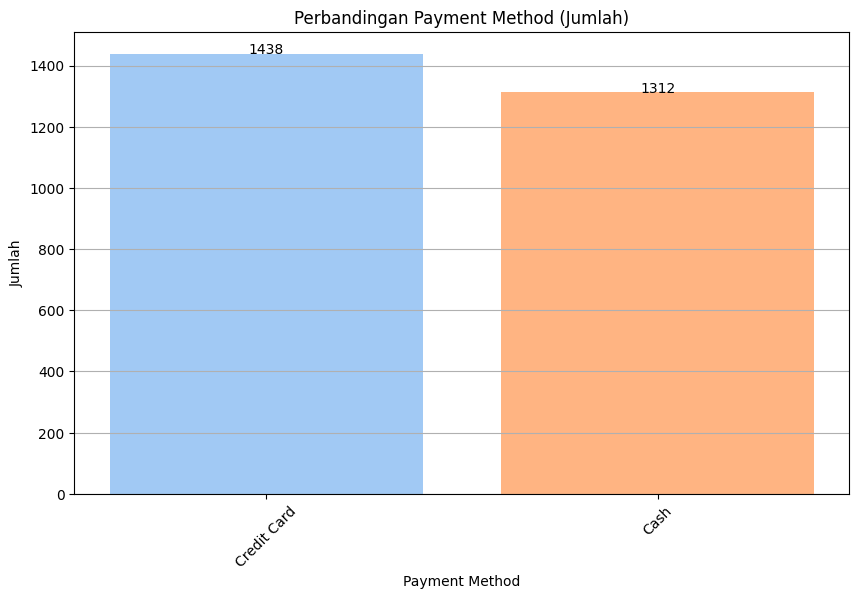

In [14]:
# Perbandingan Payment Method dalam persentase
payment_method_counts = df_fashion_retail['payment_method'].value_counts(normalize=True) * 100

# perbandingan payment method dalam jumlah
payment_method_counts_absolute = df_fashion_retail['payment_method'].value_counts()


# Visualisasi Perbandingan Payment Method dengan pie chart
plt.figure(figsize=(8, 8))
plt.pie(payment_method_counts, labels=payment_method_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Perbandingan Payment Method')
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is circular.
plt.show()

# Visualisasi Perbandingan Payment Method dengan bar chart
plt.figure(figsize=(10, 6))
plt.bar(payment_method_counts_absolute.index, payment_method_counts_absolute.values, color=sns.color_palette('pastel'))
for i, v in enumerate(payment_method_counts_absolute.values):
    plt.text(i, v + 0.5, str(v), color='black', ha='center', fontsize=10)
plt.title('Perbandingan Payment Method (Jumlah)')
plt.xlabel('Payment Method')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


Sebagian besar transaksi dilakukan menggunakan metode pembayaran `Credit Card`, yang mencerminkan preferensi pelanggan terhadap metode yang cepat dan praktis. Metode pembayaran alternatif mungkin kurang dimanfaatkan karena faktor seperti aksesibilitas, kenyamanan, atau promosi. Retailer dapat mempertimbangkan kerja sama strategis dengan penyedia payment gateway terpopuler untuk meningkatkan konversi, serta mempertimbangkan insentif bagi metode yang kurang populer untuk memperluas opsi pelanggan

# REKOMENDASI STRATEGIS BERDASARKAN ANALISIS

**1. Terdapat kenaikan pendapatan pada musim liburan (Winter Holiday dan Summer Holiday**)
- Mempromosikan item yang paling banyak terjual pada rentang bulan tersebut agar dapat menaikan pendapatan penjualan

**2. Item-item fashion yang paling banyak terjual didominasi oleh produk-produk tertentu yang memiliki permintaan tinggi.** 
- Retailer dapat fokus pada stok dan promosi produk-produk ini untuk meningkatkan pendapatan serta mempertahankan loyalitas pelanggan. 
- Produk dengan performa tinggi bisa menjadi acuan untuk pengembangan produk baru yang serupa

**3. Item-item yang menghasilkan pendapatan tertinggi tidak selalu merupakan item yang paling banyak terjual.** 
- Produk dengan margin harga tinggi yang berkontribusi signifikan terhadap total revenue. 
- Retailer dapat memanfaatkan hal ini untuk menyusun strategi upselling atau menyoroti produk high-ticket melalui promosi eksklusif dan bundling

**4. Presentase metode pembayaran didominasi menggunakan credit card**
- Retailer dapat mempertimbangkan kerja sama strategis dengan penyedia payment gateway terpopuler untuk meningkatkan konversi, serta mempertimbangkan insentif bagi metode yang kurang populer untuk memperluas opsi pelanggan (seperti cashback dan yang lainnya)

# Selanjutnya, untuk analisis LRFM, kita akan definisikan:

- **`Length`: Berapa lama pelanggan aktif (antara transaksi pertama dan terakhir)**

- **`Recency`: Seberapa lama sejak terakhir kali pelanggan membeli (semakin kecil, semakin baru)**

- **`Frequency`: Berapa kali mereka bertransaksi**

- **`Monetary`: Total uang yang dibelanjakan**

In [15]:
df_fashion_retail.columns

Index(['customer_reference_id', 'item_purchased', 'purchase_amount_usd',
       'date_purchase', 'review_rating', 'payment_method'],
      dtype='object')

In [16]:
# Tentukan tanggal referensi untuk menghitung recency (misalnya hari setelah transaksi terakhir)
reference_date = df_fashion_retail['date_purchase'].max() + pd.Timedelta(days=1)

# Hitung LRFM
lrfm = df_fashion_retail.groupby('customer_reference_id').agg({
    'date_purchase': [
        lambda x: (x.max() - x.min()).days,  # Length
        lambda x: (reference_date - x.max()).days,  # Recency
        'count'  # Frequency
    ],
    'purchase_amount_usd': 'sum'  # Monetary
})

# Rename kolom
lrfm.columns = ['Length', 'Recency', 'Frequency', 'Monetary']
lrfm = lrfm.reset_index()

# Tampilkan 5 baris pertama dari hasil LRFM
lrfm

,customer_reference_id,Length,Recency,Frequency,Monetary
0,3957,278,86,11,1150.0
1,3958,316,18,17,1334.0
2,3959,285,49,19,2047.0
3,3960,318,18,15,1434.0
4,3961,326,34,17,1811.0
...,...,...,...,...,...
161,4118,335,18,19,1899.0
162,4119,336,18,13,1357.0
163,4120,348,2,18,2081.0
164,4121,295,64,17,2035.0


Berikut penjelasan dari masing-masing variabel diatas:

| Variable | Description |
| --- | --- |
| Customer Reference ID | ID customer|
| length | Selisih tanggal transaksi customer, diperoleh dari selisih hari pertama bertransaksi dengan hari terakhir (refrence date +1) |
| recency | Selisih hari terakhir bertransaksi dengan hari saat ini |
| frequency | Jumlah transaksi yang dilakukan oleh customer |
| monetary | Besar pengeluaran yang dilakukan oleh customer |

### `Assigning Scores`

Selanjutnya kita akan menentukan skor dengan metode berikut:
- Rule Based: *Frequency*
- Statistical Approach: *Length, Recency,* dan *Monetary*

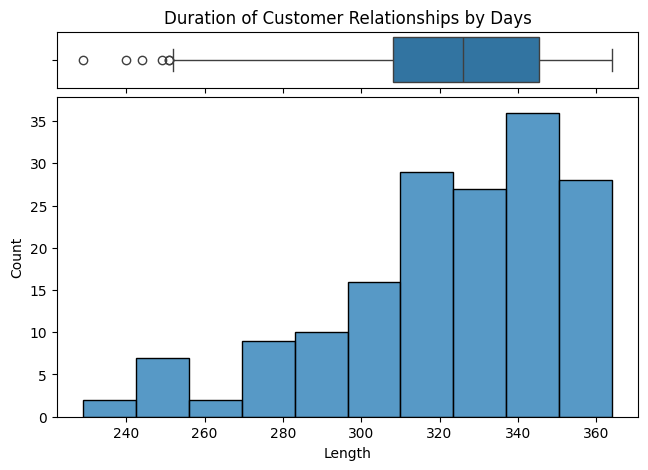

0.00    229.0
0.25    308.0
0.50    326.0
0.75    345.5
1.00    364.0
Name: Length, dtype: float64

In [17]:
fig, (ax_top, ax_bot) = plt.subplots(
                            nrows=2, 
                            ncols=1, 
                            figsize=(7.5, 5),
                            gridspec_kw={
                                'height_ratios': (0.15, 0.85),
                                'hspace': 0.05
                            }
                        )

sns.boxplot(data=lrfm, x='Length', ax=ax_top)
sns.histplot(data=lrfm, x='Length', ax=ax_bot)

ax_top.set(
    title='Duration of Customer Relationships by Days'
)

plt.show()
display(lrfm['Length'].quantile([0, 0.25, 0.5, 0.75, 1]))

Berdasarkan distribusi di atas, kita akan kelompokkan customer berdasarkan length-nya ke dalam 4 kelompok yaitu :
- 4 (Veteran) : telah bergabung lebih dari 345 hari
- 3 (Established) : telah bergabung antara 326 hingga 345 hari terakhir
- 2 (Acquainted) : telah bergabung antara 308 hingga 326 hari terakhir
- 1 (Newcomer) : baru bergabung antara 1 hingga 229 hari terakhir

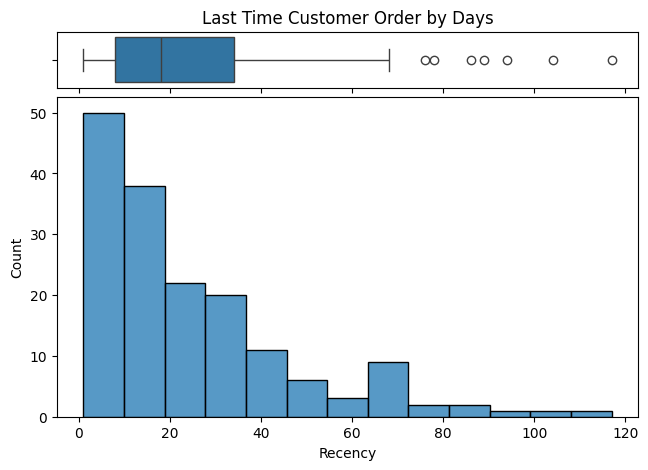

0.00      1.0
0.25      8.0
0.50     18.0
0.75     34.0
1.00    117.0
Name: Recency, dtype: float64

In [18]:
fig, (ax_top, ax_bot) = plt.subplots(
                            nrows=2, 
                            ncols=1, 
                            figsize=(7.5, 5),
                            gridspec_kw={
                                'height_ratios': (0.15, 0.85),
                                'hspace': 0.05
                            }
                        )

sns.boxplot(data=lrfm, x='Recency', ax=ax_top)
sns.histplot(data=lrfm, x='Recency', ax=ax_bot)

ax_top.set(
    title='Last Time Customer Order by Days'
)

plt.show()
display(lrfm['Recency'].quantile([0, 0.25, 0.5, 0.75, 1]))

Berdasarkan distribusi di atas, kita akan kelompokkan customer berdasarkan recency-nya ke dalam 4 kelompok yaitu :
- 4 (Active) : melakukan transaksi kurang dari 8 hari terakhir
- 3 (Warm) : melakukan transaksi antara 8 hingga 18 hari terakhir
- 2 (Cold) : melakukan transaksi antara 34 hingga 117 hari terakhir
- 1 (Inactive) : melakukan transaksi lebih dari 117 hari terakhir

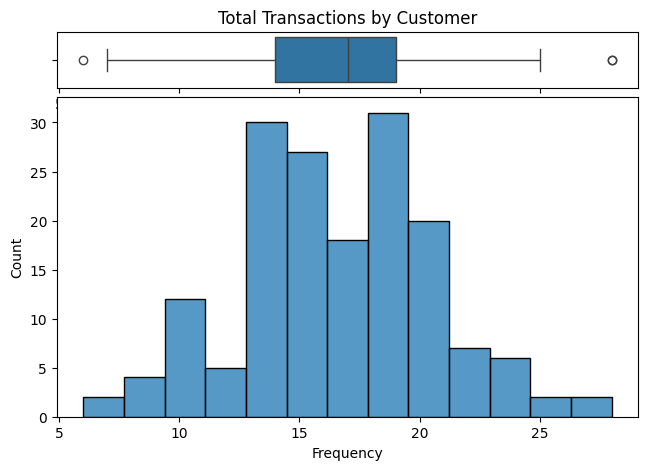

0.00     6.0
0.25    14.0
0.50    17.0
0.75    19.0
1.00    28.0
Name: Frequency, dtype: float64

In [19]:
fig, (ax_top, ax_bot) = plt.subplots(
                            nrows=2, 
                            ncols=1, 
                            figsize=(7.5, 5),
                            gridspec_kw={
                                'height_ratios': (0.15, 0.85),
                                'hspace': 0.05
                            }
                        )

sns.boxplot(data=lrfm, x='Frequency', ax=ax_top)
sns.histplot(data=lrfm, x='Frequency', ax=ax_bot)

ax_top.set(
    title='Total Transactions by Customer'
)

plt.show()
display(lrfm['Frequency'].quantile([0, 0.25, 0.5, 0.75, 1]))

Berdasarkan distribusi di atas, kita akan kelompokkan customer berdasarkan frequency-nya ke dalam 4 kelompok mengacu pada jumlah transaksi yang kita tentukan yaitu:
- 4 (Loyal) : melakukan transaki lebih dari 19 kali
- 3 (High) : melakukan transaksi 18 hingga 19 kali
- 2 (Medium) : melakukan transaksi 15 hingga 17 kali
- 1 (Low) : melakukan transaksi hanya 6 kali.

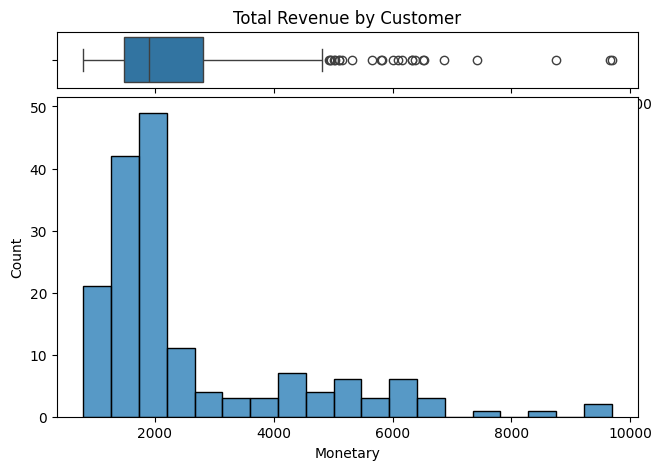

0.00     802.00
0.25    1486.25
0.50    1905.50
0.75    2815.25
1.00    9685.00
Name: Monetary, dtype: float64

In [20]:
fig, (ax_top, ax_bot) = plt.subplots(
                            nrows=2, 
                            ncols=1, 
                            figsize=(7.5, 5),
                            gridspec_kw={
                                'height_ratios': (0.15, 0.85),
                                'hspace': 0.05
                            }
                        )

sns.boxplot(data=lrfm, x='Monetary', ax=ax_top)
sns.histplot(data=lrfm, x='Monetary', ax=ax_bot)

ax_top.set(
    title='Total Revenue by Customer'
)

plt.show()
display(lrfm['Monetary'].quantile([0, 0.25, 0.5, 0.75, 1]))

Berdasarkan distribusi di atas, kita akan kelompokkan customer berdasarkan monetary-nya ke dalam 4 kelompok yaitu :
- 4 (Top Spender) : melakukan transaksi lebih dari 2815.25 dollar
- 3 (High Spender) : melakukan transaksi antara 1905.5 hingga 2815.2 dollar
- 2 (Medium Spender) : melakukan transaksi antara 1486.25 hingga 1905.49 dollar
- 1 (Low Spender) : melakukan transaksi kurang dari dari 1486.25 dollar

# Interpretasi Segmentasi:
- **`Champions (14-16)`: Pelanggan terbaik – sering beli, terakhir baru, dan belanja besar.**

- **`Loyal Customers (11-13)`: Pelanggan setia – sering beli dan konsisten.**

- **`Potential Loyalists (8-10)`: Perlu perhatian lebih, berpotensi jadi loyal.**

- **`Needs Attention (5-7)`: Aktivitas rendah, bisa ditingkatkan dengan promosi.**

- **`At Risk (0-4)`: Hampir hilang, perlu retensi segera.**

In [21]:
# Buat skor kuartil untuk setiap komponen LRFM
lrfm['L_score'] = pd.qcut(lrfm['Length'], 4, labels=[1, 2, 3, 4])
lrfm['R_score'] = pd.qcut(lrfm['Recency'], 4, labels=[4, 3, 2, 1])  # Lebih kecil recency = lebih bagus
lrfm['F_score'] = pd.qcut(lrfm['Frequency'], 4, labels=[1, 2, 3, 4])
lrfm['M_score'] = pd.qcut(lrfm['Monetary'], 4, labels=[1, 2, 3, 4])

# Gabungkan skor menjadi segmen
lrfm['LRFM_Score'] = (
    lrfm['L_score'].astype(str) +
    lrfm['R_score'].astype(str) +
    lrfm['F_score'].astype(str) +
    lrfm['M_score'].astype(str)
)

# Segmentasi berdasarkan skor total (bisa juga menggunakan clustering nantinya)
lrfm['Total_Score'] = (
    lrfm[['L_score', 'R_score', 'F_score', 'M_score']].astype(int).sum(axis=1)
)

# Buat kategori segmentasi sederhana
def segment_customer(score):
    if score >= 14:
        return 'Champions'
    elif score >= 11:
        return 'Loyal Customers'
    elif score >= 8:
        return 'Potential Loyalists'
    elif score >= 5:
        return 'Needs Attention'
    else:
        return 'At Risk'

lrfm['Segment'] = lrfm['Total_Score'].apply(segment_customer)

# Tampilkan hasil segmentasi
lrfm[['customer_reference_id', 'LRFM_Score', 'Total_Score', 'Segment']]

,customer_reference_id,LRFM_Score,Total_Score,Segment
0,3957,1111,4,At Risk
1,3958,2321,8,Potential Loyalists
2,3959,1133,8,Potential Loyalists
3,3960,2321,8,Potential Loyalists
4,3961,2222,8,Potential Loyalists
...,...,...,...,...
161,4118,3332,11,Loyal Customers
162,4119,3311,8,Potential Loyalists
163,4120,4433,14,Champions
164,4121,1123,7,Needs Attention


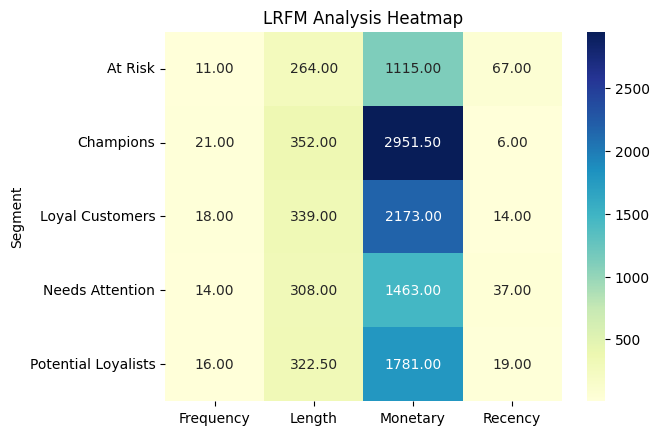

In [22]:
lrfm_heatmap = lrfm.pivot_table(index='Segment', values=['Length', 'Recency', 'Frequency', 'Monetary'], aggfunc='median')

# Create the heatmap
sns.heatmap(lrfm_heatmap, cmap='YlGnBu', annot=True, fmt=".2f")
plt.title('LRFM Analysis Heatmap')
plt.show()

C:\Users\Ikhsan Herdi F\AppData\Local\Temp\ipykernel_13296\3199947588.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_counts, x='Segment', y='Jumlah Pelanggan', palette='viridis')


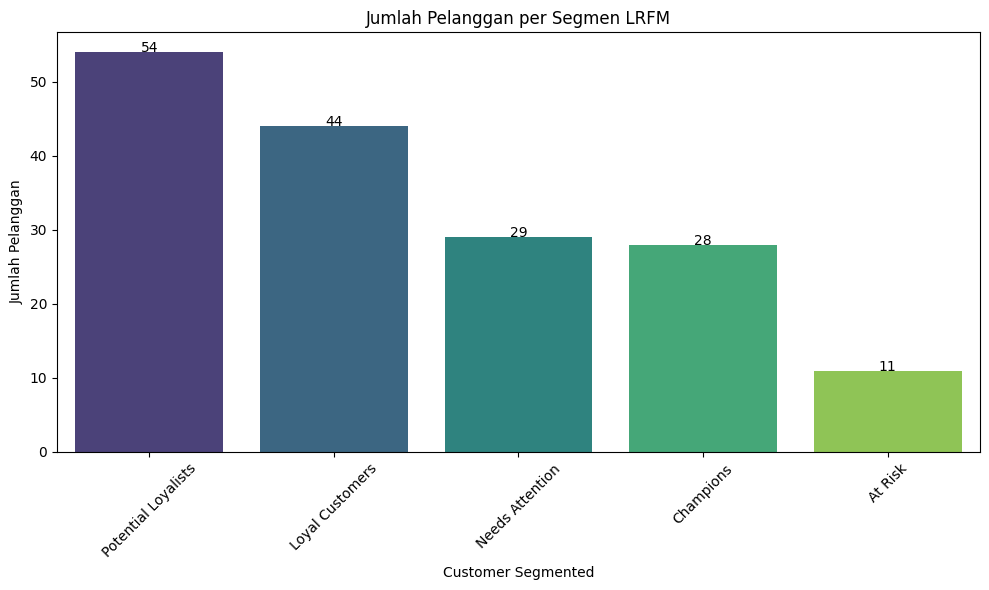

In [23]:
# Hitung jumlah pelanggan per segmen
segment_counts = lrfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Jumlah Pelanggan']

# Plot batang
plt.figure(figsize=(10, 6))
sns.barplot(data=segment_counts, x='Segment', y='Jumlah Pelanggan', palette='viridis')
for index, row in segment_counts.iterrows():
    plt.text(index, row['Jumlah Pelanggan'], row['Jumlah Pelanggan'], color='black', ha="center")
plt.title('Jumlah Pelanggan per Segmen LRFM')
plt.xlabel('Customer Segmented')
plt.ylabel('Jumlah Pelanggan')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
import plotly.express as px

color_map = {'Bronze' : 'brown', 'Silver' : 'gray', 'Gold' : 'orange', 'Platinum' : 'red'}

fig = px.scatter_3d(
    lrfm, 
    x='Recency', 
    y='Frequency', 
    z='Monetary',
    color='Segment', 
    color_discrete_map=color_map, 
)
                          
fig.update_traces(marker_size = 3)

# tight layout
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0),
                  title={
                    'text': "LRFM segmentation",
                    'y':0.97,
                    'x':0.45,
                    'xanchor': 'center',
                    'yanchor': 'top'},
                    legend=dict(
                      yanchor="top",
                      y=0.97,
                      xanchor="left",
                      x=0.70,
                      itemsizing='constant',
                      itemwidth = 30))

fig.update_xaxes(tickformat=".0f")


In [25]:
# menampilkan 10 pelangggan dengan status Champions
champions = lrfm[lrfm['Segment'] == 'Potential Loyalists']
champions[['customer_reference_id', 'Length', 'Recency', 'Frequency', 'Monetary', 'LRFM_Score', 'Total_Score']]

,customer_reference_id,Length,Recency,Frequency,Monetary,LRFM_Score,Total_Score
1,3958,316,18,17,1334.0,2321,8
2,3959,285,49,19,2047.0,1133,8
3,3960,318,18,15,1434.0,2321,8
4,3961,326,34,17,1811.0,2222,8
6,3963,351,12,14,1592.0,4312,10
7,3964,310,17,17,1841.0,2322,9
9,3966,348,15,13,1644.0,4312,10
14,3971,322,34,15,1493.0,2222,8
15,3972,263,78,18,4938.0,1134,9
18,3975,316,3,11,1010.0,2411,8


Kita akan kelompokkan kedalam 4 segmen dengan ketentuan berikut:

In [26]:
seg_map = {
    r'[1-2][1-4][1-4][1-2]': 'New Cust Low Value',
    r'[1-2][1-4][1-4][3-4]': 'New Cust High Value',
    r'[3-4][1-2][1-2][1-2]': 'Old Cust Inactive',
    r'[3-4][1-2][1-4][1-4]': 'At Risk', 
    r'[3-4][1-2][3-4][3-4]': 'Need Attention',
    r'[3-4][3-4][3-4][3-4]': 'Loyal Cust',
    r'[3-4][3-4][3-4][1-2]': 'Potensial Loyal Cust',
    r'[3-4][3-4][1-2][1-4]': 'Reactivated Old Cust'    
}
    
lrfm['LRFM_Segment_Combine'] = lrfm['LRFM_Score'].replace(seg_map, regex=True)
lrfm.sample(5, random_state=42)

,customer_reference_id,Length,Recency,Frequency,Monetary,L_score,R_score,F_score,M_score,LRFM_Score,Total_Score,Segment,LRFM_Segment_Combine
100,4057,354,4,18,1680.0,4,4,3,2,4432,13,Loyal Customers,Potensial Loyal Cust
136,4093,357,8,18,1792.0,4,4,3,2,4432,13,Loyal Customers,Potensial Loyal Cust
78,4035,253,68,12,5151.0,1,1,1,4,1114,7,Needs Attention,New Cust High Value
56,4013,319,41,16,1463.0,2,1,2,1,2121,6,Needs Attention,New Cust Low Value
97,4054,282,25,16,5315.0,1,2,2,4,1224,9,Potential Loyalists,New Cust High Value


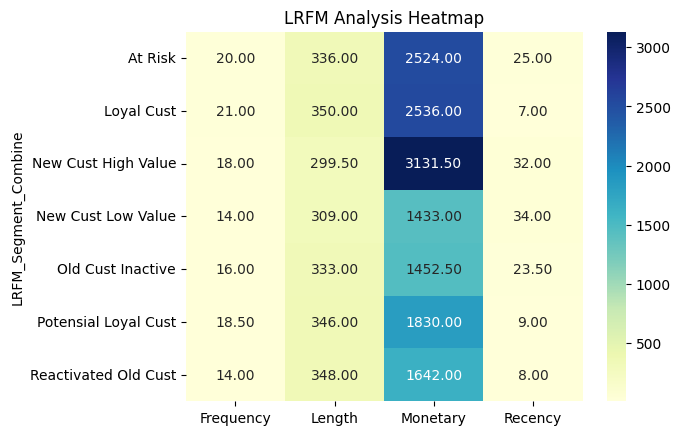

In [27]:
lrfm_heatmap = lrfm.pivot_table(index='LRFM_Segment_Combine', values=['Length', 'Recency', 'Frequency', 'Monetary'], aggfunc='median')

# Create the heatmap
sns.heatmap(lrfm_heatmap, cmap='YlGnBu', annot=True, fmt=".2f")
plt.title('LRFM Analysis Heatmap')
plt.show()

In [28]:
import plotly.express as px

color_map = {
    'Loyal Cust' : 'gray',
    'Potensial Loyal Cust' : 'purple',
    'New Cust High Value' : 'pink',
    'New Cust Low Value' : 'blue',
    'Need Attention' : 'green',
    'At Risk' : 'yellow', 
    'Reactivated Old Cust' : 'orange', 
    'Old Cust Inactive' : 'red',
}

fig = px.scatter_3d(
    lrfm, 
    x='Recency', 
    y='Frequency', 
    z='Monetary',
    color='LRFM_Segment_Combine', 
    color_discrete_map=color_map, 
)
                          
fig.update_traces(marker_size = 3)

# tight layout
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0),
                  title={
                    'text': "RFM segmentation",
                    'y':0.97,
                    'x':0.45,
                    'xanchor': 'center',
                    'yanchor': 'top'},
                    legend=dict(
                      yanchor="top",
                      y=0.97,
                      xanchor="left",
                      x=0.70,
                      itemsizing='constant',
                      itemwidth = 30))

fig.update_xaxes(tickformat=".0f")

In [29]:
lrfm

,customer_reference_id,Length,Recency,Frequency,Monetary,L_score,R_score,F_score,M_score,LRFM_Score,Total_Score,Segment,LRFM_Segment_Combine
0,3957,278,86,11,1150.0,1,1,1,1,1111,4,At Risk,New Cust Low Value
1,3958,316,18,17,1334.0,2,3,2,1,2321,8,Potential Loyalists,New Cust Low Value
2,3959,285,49,19,2047.0,1,1,3,3,1133,8,Potential Loyalists,New Cust High Value
3,3960,318,18,15,1434.0,2,3,2,1,2321,8,Potential Loyalists,New Cust Low Value
4,3961,326,34,17,1811.0,2,2,2,2,2222,8,Potential Loyalists,New Cust Low Value
...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,4118,335,18,19,1899.0,3,3,3,2,3332,11,Loyal Customers,Potensial Loyal Cust
162,4119,336,18,13,1357.0,3,3,1,1,3311,8,Potential Loyalists,Reactivated Old Cust
163,4120,348,2,18,2081.0,4,4,3,3,4433,14,Champions,Loyal Cust
164,4121,295,64,17,2035.0,1,1,2,3,1123,7,Needs Attention,New Cust High Value


# REKOMENDASI STRATEGI

**1. Champions (Skor 14–16)**<br>
Karakteristik: Pelanggan paling berharga – sering beli, pembelian besar, dan baru belanja.

Strategi:

- Berikan early access ke koleksi baru.

- Tawarkan loyalty program eksklusif.

- Kirimkan thank you email atau hadiah kejutan (misalnya voucher).

- Ajak ikut program referral dengan insentif menarik.

- Kumpulkan feedback: "Apa yang membuat mereka loyal?"

**2. Loyal Customers (Skor 11–13)**<br>
Karakteristik: Sering beli, konsisten, tapi tak selalu belanja besar.

Strategi:

- Tawarkan bundle deals atau diskon untuk pembelian selanjutnya.

- Dorong mereka untuk naik ke level Champions dengan insentif tambahan.

- Kirimkan newsletter personalisasi produk sesuai histori mereka.

- Ajak mereka menulis review produk → kasih reward poin/voucher.

**3. Potential Loyalists (Skor 8–10)**<br>
Karakteristik: Baru mulai aktif, atau belum rutin belanja tapi potensial.

Strategi:

- Kirim email "Kami merindukanmu" disertai diskon khusus.

- Dorong pembelian kedua/ketiga dengan promo waktu terbatas.

- Personalisasi konten berdasarkan histori pembelian pertama.

- Upsell dengan produk pelengkap dari item sebelumnya.

**4. Needs Attention (Skor 5–7)**<br>
Karakteristik: Tidak sering belanja dan jarang terakhir aktif.

Strategi:

- Kirim reminder dan diskon menarik seperti “Beli Lagi, Dapat Diskon 20%”.

- Ajak ikut dalam flash sale/event musiman (misalnya Ramadan Sale).

- Tawarkan produk trending atau best-seller yang belum mereka coba.

- Gunakan iklan retargeting jika mereka pernah browsing tanpa membeli.

**At Risk (Skor 0–4)**<br>
Karakteristik: Hampir hilang, sudah lama tidak aktif, belanja rendah.

Strategi:

- Kirim email reaktivasi dramatis (“Kami ingin kamu kembali”).

- Berikan kode diskon besar untuk pembelian berikutnya.

- Sampaikan nilai eksklusif dari brand: kualitas, limited stock, testimonial.

- Undang ke survey singkat untuk tahu alasan mereka tidak kembali.

In [30]:
# convert lrfm into json file
lrfm.to_json('lrfm_fashion_retail.json', index=False)

In [31]:
# convert df_fashion_retail into json file
df_fashion_retail.to_json('fashion_retail_fix_cleaned.json', index=False)

# Mengkoneksikan BigQuery dengan Pandas

In [32]:
from google.oauth2 import service_account
import pandas_gbq

# bigquery configuration
project_id = 'strategic-guru-456806-r3'
dataset_id = 'fashion_retail_analysis'
table_id1 = 'fashion_retail'
table_id2 = 'lrfm_fashion_retail'
key_path = r"D:\Purwadhika School - JCDS2804\Module 2 - Data Analyst\Portofolio Project\strategic-guru-456806-r3-ffe07732bbe4.json"
scopes = ['https://www.googleapis.com/auth/bigquery']
credentials = service_account.Credentials.from_service_account_file(key_path, scopes=scopes)

# Upload fashion_retail_fix_cleaned to BigQuery
pandas_gbq.to_gbq(
    df_fashion_retail, 
    f'{dataset_id}.{table_id1}', 
    project_id=project_id, 
    if_exists='replace', 
    credentials=credentials
)

# Upload lrfm_fashion_retail to BigQuery
pandas_gbq.to_gbq(
    lrfm, 
    f'{dataset_id}.{table_id2}', 
    project_id=project_id, 
    if_exists='replace', 
    credentials=credentials
)


100%|██████████| 1/1 [00:00<00:00, 12710.01it/s]
c:\Users\Ikhsan Herdi F\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas_gbq\schema\pandas_to_bigquery.py:157: UserWarning:

Could not determine the type of columns: L_score, R_score, F_score, M_score

100%|██████████| 1/1 [00:00<00:00, 10180.35it/s]
